In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-whitegrid')
%matplotlib inline

import tensorflow as tf

C:\Users\ATISHAY SG\AppData\Local\Temp\ipykernel_24832\3405315510.py:3: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


In [2]:
tf.__version__

'2.14.0'

[ 0  1  2  3  4  5  6  7  8  9 10] [ 0.89814717  2.71770578  4.30059155  7.33107335  9.05383476 11.38411903
 12.69241735 15.27168133 16.75844767 18.25423665 20.82647405]


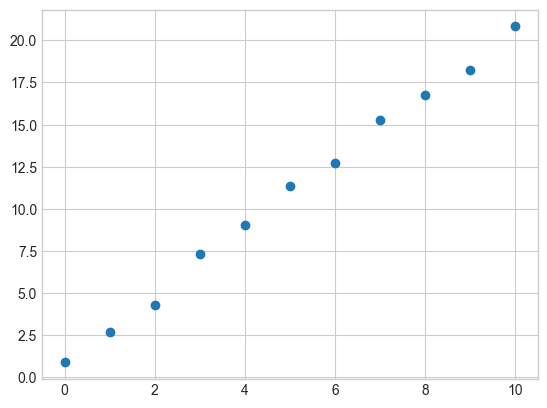

In [3]:
x_train = np.arange(11)
y_train = 2 * x_train + 1 + np.random.normal(0, 0.5, len(x_train))
print(x_train, y_train)
plt.scatter(x_train, y_train)

Initialize the weights as a single matrix.   
initializer


In [4]:
# w1 = tf.Variable(0.01 * np.random.normal())
# w2 = tf.Variable(0.01 * np.random.normal())

In [4]:
w1 = tf.keras.initializers.random_normal()
w2 = tf.keras.initializers.random_normal()

w1 = tf.Variable(w1(shape=()))
w2 = tf.Variable(w2(shape=()))

---

Loss Function

---

In [6]:
def mse_loss(y, yhat):
    return tf.reduce_mean(tf.square(y - yhat))

Gradient and loss function for one step

In [7]:
# def onestep(x, y, learning_rate=0.01):
#     with tf.GradientTape(persistent=True) as g:
#         yhat = w1*x + w2  # forward pass later rewrite this as Wx_B
#         loss = mse_loss(y, yhat) # Calculate loss

#     # Calculate gradients
#     w1_grad, w2_grad = g.gradient(loss, w1), g.gradient(loss, w2)
#     print('w1_grad:', w1_grad)

#     # Update weights
#     w1.assign_sub(w1_grad * learning_rate)
#     w2.assign_sub(w2_grad * learning_rate)

In [7]:
def onestep(x, y, learning_rate=0.01):
    with tf.GradientTape(persistent=True) as g:
        z = w1*x + w2  # forward pass later rewrite this as Wx_B
        a = np.tanh(z)

        z2 = w1 * a + w2

        loss = mse_loss(y, z2)

        # Convert tensor to numpy array and print its shape
        z2_array = z2.numpy()
        print(z2_array.shape)
        
    # Calculate gradients
    gradL_w = g.gradient(loss, [w1, w2])
    print('w1_grad:', gradL_w)
    print('w2_grad:', gradL_w[1])

    # Update weights
    w1.assign_sub(gradL_w[0] * learning_rate)
    w2.assign_sub(gradL_w[1] * learning_rate)

    return loss

---

Training loop

---

In [9]:
# batch_size = 1
loss_values = []
niters = 100

for iter in range(niters):
    onestep(x_train, y_train)
    loss_values.append(onestep(x_train, y_train))


(11,)
w1_grad: [<tf.Tensor: shape=(), dtype=float32, numpy=11.959948>, <tf.Tensor: shape=(), dtype=float32, numpy=-21.97705>]
w2_grad: tf.Tensor(-21.97705, shape=(), dtype=float32)
(11,)
w1_grad: [<tf.Tensor: shape=(), dtype=float32, numpy=16.507996>, <tf.Tensor: shape=(), dtype=float32, numpy=-21.376743>]
w2_grad: tf.Tensor(-21.376743, shape=(), dtype=float32)
(11,)
w1_grad: [<tf.Tensor: shape=(), dtype=float32, numpy=18.318914>, <tf.Tensor: shape=(), dtype=float32, numpy=-20.695862>]
w2_grad: tf.Tensor(-20.695862, shape=(), dtype=float32)
(11,)
w1_grad: [<tf.Tensor: shape=(), dtype=float32, numpy=18.495993>, <tf.Tensor: shape=(), dtype=float32, numpy=-20.001984>]
w2_grad: tf.Tensor(-20.001984, shape=(), dtype=float32)
(11,)
w1_grad: [<tf.Tensor: shape=(), dtype=float32, numpy=18.177242>, <tf.Tensor: shape=(), dtype=float32, numpy=-19.325188>]
w2_grad: tf.Tensor(-19.325188, shape=(), dtype=float32)
(11,)
w1_grad: [<tf.Tensor: shape=(), dtype=float32, numpy=17.701138>, <tf.Tensor: shap

w1_grad: [<tf.Tensor: shape=(), dtype=float32, numpy=16.081274>, <tf.Tensor: shape=(), dtype=float32, numpy=-16.841927>]
w2_grad: tf.Tensor(-16.841927, shape=(), dtype=float32)
(11,)
w1_grad: [<tf.Tensor: shape=(), dtype=float32, numpy=15.547333>, <tf.Tensor: shape=(), dtype=float32, numpy=-16.273972>]
w2_grad: tf.Tensor(-16.273972, shape=(), dtype=float32)
(11,)
w1_grad: [<tf.Tensor: shape=(), dtype=float32, numpy=15.027272>, <tf.Tensor: shape=(), dtype=float32, numpy=-15.725647>]
w2_grad: tf.Tensor(-15.725647, shape=(), dtype=float32)
(11,)
w1_grad: [<tf.Tensor: shape=(), dtype=float32, numpy=14.52289>, <tf.Tensor: shape=(), dtype=float32, numpy=-15.196259>]
w2_grad: tf.Tensor(-15.196259, shape=(), dtype=float32)
(11,)
w1_grad: [<tf.Tensor: shape=(), dtype=float32, numpy=14.034848>, <tf.Tensor: shape=(), dtype=float32, numpy=-14.685133>]
w2_grad: tf.Tensor(-14.685133, shape=(), dtype=float32)
(11,)
w1_grad: [<tf.Tensor: shape=(), dtype=float32, numpy=13.563203>, <tf.Tensor: shape=(),

In [8]:
print(w1.numpy(), w2.numpy())

0.11667466 0.114799395
